## 0. Importación de librerias y carga de datos

In [249]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import missingno as msno

# Import zscore function
from scipy.stats import zscore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Utils
import math
import re
import unicodedata
from pyod.models.mad import MAD

In [250]:
paths = {
    "banco_sangre": r"..\data\processed\df_banco_sangre_times_series.csv",
    "defunciones": r"..\data\processed\df_defunciones_sangre_time_series.csv",
    "hospitalizados": r"..\data\processed\df_hospitalizados_time_series.csv",
}

dataframes = {}

for var_name, file in paths.items():
    print(f"Loading data from: {file}")
    try:
        dataframes[var_name] = pd.read_csv(file, low_memory=False)
        print(f"'{var_name}' loaded successfully. Shape: {dataframes[var_name].shape}")
    except FileNotFoundError:
        print(f"Error: File not found → {file}")
        dataframes[var_name] = None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        dataframes[var_name] = None
    except pd.errors.ParserError:
        print("Error: The file content could not be parsed.")
        dataframes[var_name] = None
    except PermissionError:
        print("Error: Permission denied when accessing the file.")
        dataframes[var_name] = None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        dataframes[var_name] = None

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones = dataframes["defunciones"]
df_hospitalizados = dataframes["hospitalizados"]

print("\nDimensiones de los DataFrames:")
print("Banco de Sangre:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Hospitalizados:", df_hospitalizados.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\processed\df_banco_sangre_times_series.csv
'banco_sangre' loaded successfully. Shape: (1321, 2)
Loading data from: ..\data\processed\df_defunciones_sangre_time_series.csv
'defunciones' loaded successfully. Shape: (452, 2)
Loading data from: ..\data\processed\df_hospitalizados_time_series.csv
'hospitalizados' loaded successfully. Shape: (1251, 2)

Dimensiones de los DataFrames:
Banco de Sangre:       (1321, 2)
Defunciones: (452, 2)
Hospitalizados: (1251, 2)


## 1. Estandarización y rango de fechas

In [251]:
# Estandarización de fechas
df_banco_sangre["fecha_extraccion"] = pd.to_datetime(
    df_banco_sangre["fecha_extraccion"]
)
df_defunciones["fecha_defuncion"] = pd.to_datetime(df_defunciones["fecha_defuncion"])
df_hospitalizados["fecha_atencion"] = pd.to_datetime(
    df_hospitalizados["fecha_atencion"]
)

# Rango de fechas por variable
rango_fechas = {
    "Banco de Sangre": (
        df_banco_sangre["fecha_extraccion"].min(),
        df_banco_sangre["fecha_extraccion"].max(),
    ),
    "Defunciones": (
        df_defunciones["fecha_defuncion"].min(),
        df_defunciones["fecha_defuncion"].max(),
    ),
    "Hospitalizados": (
        df_hospitalizados["fecha_atencion"].min(),
        df_hospitalizados["fecha_atencion"].max(),
    ),
}

print("\nRango de fechas por variable:")
for var, (start, end) in rango_fechas.items():
    print(f"{var}: Del {start.date()} a {end.date()}")


Rango de fechas por variable:
Banco de Sangre: Del 2020-01-02 a 2025-06-27
Defunciones: Del 2022-01-02 a 2026-03-31
Hospitalizados: Del 2022-01-02 a 2026-03-31


## 2. Imputacione de ceros en donaciones
En el notebook 2_EDA_banco_sangre en el Heatmap donaciones x año (punto 2.2), ahí notamos que entre enero de 2024 y mayo del mismo año no hay registro de donaciones, por eso procedemos a imputar con interpolación estacional con el promedio histórico por mes para usar mas datos y asi mejorar la capacidad de predicción de la serie de timpo

Fechas faltantes en Ene-May 2024: 152
Filas a imputar: 152

Mediana diaria de referencia por mes:
mes
1     23.0
2     17.5
3     14.0
4     14.0
5     13.0
6     13.0
7     18.0
8     18.0
9     11.0
10    17.0
11    16.5
12    13.0
Name: donaciones_diarias, dtype: float64


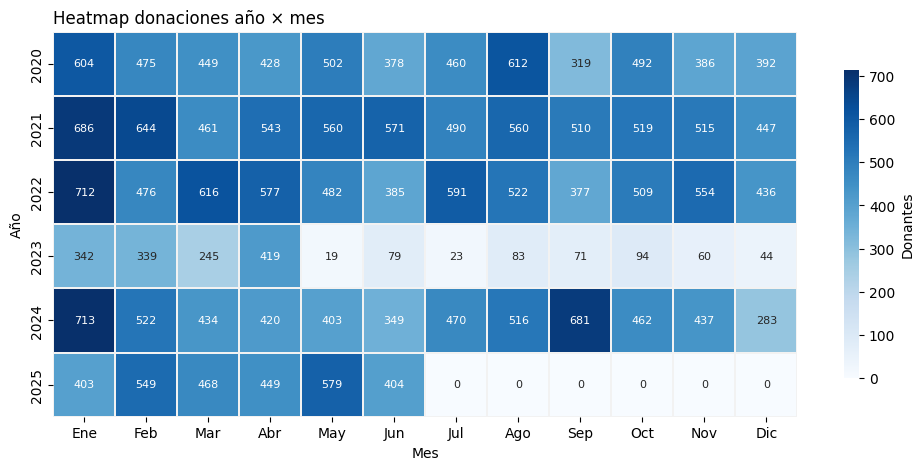

In [252]:
# 1. Ordenar fechas de extracción en df_banco_sangre y crear columna de meses
df_banco_sangre = df_banco_sangre.sort_values("fecha_extraccion").reset_index(drop=True)
MESES = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

# 2. Crear el rango completo SOLO para el hueco Ene-May 2024
rango_hueco = pd.date_range("2024-01-01", "2024-05-31", freq="D")

# 3. Ver cuáles de esas fechas ya existen en df_banco_sangre, y cuáles faltan
fechas_existentes = set(df_banco_sangre["fecha_extraccion"])
fechas_faltantes = [f for f in rango_hueco if f not in fechas_existentes]

print(f"Fechas faltantes en Ene-May 2024: {len(fechas_faltantes)}")

# 4. Crear filas nuevas para esas fechas faltantes, con NaN en donaciones_diarias
filas_nuevas = pd.DataFrame(
    {"fecha_extraccion": fechas_faltantes, "donaciones_diarias": np.nan}
)

# 5. Concatenar y reordenar
df_banco_sangre = pd.concat([df_banco_sangre, filas_nuevas], ignore_index=True)
df_banco_sangre = df_banco_sangre.sort_values("fecha_extraccion").reset_index(drop=True)

# 6. Extraer año y mes
df_banco_sangre["año"] = df_banco_sangre["fecha_extraccion"].dt.year
df_banco_sangre["mes"] = df_banco_sangre["fecha_extraccion"].dt.month

# 7. Identificar las filas a imputar (las que acabamos de crear, con NaN, en el hueco)
mascara_hueco = (df_banco_sangre["año"] == 2024) & (
    df_banco_sangre["mes"].isin([1, 2, 3, 4, 5])
)
mascara_imputar = mascara_hueco & (df_banco_sangre["donaciones_diarias"].isna())

print(f"Filas a imputar: {mascara_imputar.sum()}")

# 8. Mediana histórica por mes, usando años de referencia confiables
anios_referencia = [2020, 2021, 2022]

mediana_por_mes = (
    df_banco_sangre[df_banco_sangre["año"].isin(anios_referencia)]
    .groupby("mes")["donaciones_diarias"]
    .median()
)

print("\nMediana diaria de referencia por mes:")
print(mediana_por_mes)

# 9. Imputar
df_banco_sangre.loc[mascara_imputar, "donaciones_diarias"] = (
    df_banco_sangre.loc[mascara_imputar, "mes"].map(mediana_por_mes).round().astype(int)
)

# 10. Visualizar el heatmap de donaciones por año y mes despues de la imputación
pivot = (
    df_banco_sangre.groupby(["año", "mes"])["donaciones_diarias"]
    .sum()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(columns=range(1, 13), fill_value=0)
pivot.columns = MESES
pivot = pivot.fillna(0).astype(int)  # <-- esta línea es el fix

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="Blues",
    linewidths=0.3,
    linecolor="#F2F2F2",
    annot=True,
    fmt="d",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Donantes"},
)
ax.set_title("Heatmap donaciones año × mes", loc="left")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.show()

# 11. Limpiar columnas auxiliares
df_banco_sangre = df_banco_sangre.drop(columns=["año", "mes"])

## 3. Preparación serie temporal

In [253]:
# Construir dataset de modelado
DATE_START = "2022-01-02"
DATE_END = "2025-06-27"

# Rango completo de fechas diarias
idx = pd.date_range(DATE_START, DATE_END, freq="D", name="fecha")

# Donaciones diarias
ser_don = (
    df_banco_sangre.assign(fecha=pd.to_datetime(df_banco_sangre["fecha_extraccion"]))
    .set_index("fecha")["donaciones_diarias"]
    .resample("D")
    .sum()
    .reindex(idx, fill_value=0)
    .rename("donaciones")
)

# Hospitalizados diarios
ser_hosp = (
    df_hospitalizados.assign(fecha=pd.to_datetime(df_hospitalizados["fecha_atencion"]))
    .set_index("fecha")["hospitalizaciones_diarias"]
    .resample("D")
    .sum()
    .reindex(idx, fill_value=0)
    .rename("hospitalizados")
)

# Muertes relacionadas con sangre
ser_muertes = (
    df_defunciones.assign(fecha=pd.to_datetime(df_defunciones["fecha_defuncion"]))
    .set_index("fecha")["defunciones_diarias"]
    .resample("D")
    .sum()
    .reindex(idx, fill_value=0)
    .rename("muertes_sangre")
)

# Combinar en un solo DataFrame
df_model = pd.concat([ser_don, ser_hosp, ser_muertes], axis=1).reset_index()

# Medias móviles de 7 días
df_model["don_media_7d"] = df_model["donaciones"].rolling(7).mean().round(1)
df_model["hosp_media_7d"] = (
    (df_model["hospitalizados"] + df_model["muertes_sangre"]).rolling(7).mean().round(1)
)

# Presión diaria y umbral crítico (τ = percentil 75)
df_model["presion"] = df_model["hosp_media_7d"] - df_model["don_media_7d"]
tau = df_model["presion"].quantile(0.75)

# Variable objetivo: escasez en t+14
# shift(-14): en la fila t se pone la presión del día t+14
presion_futura = df_model["presion"].shift(-14)
df_model["escasez_t14"] = (presion_futura > tau).astype("Int64")

# Deficit relativo
df_model["deficit_relativo"] = (
    df_model["hosp_media_7d"] - df_model["don_media_7d"]
) / df_model["hosp_media_7d"]

# Creación de lags en presion, deficit relativo, demanda y oferta
for lag in [
    1,
    3,
    7,
    14,
]:
    df_model[f"presion_lag_{lag}"] = df_model["presion"].shift(lag)
    df_model[f"deficit_lag_{lag}"] = df_model["deficit_relativo"].shift(lag)
    df_model[f"don_media_7d_lag_{lag}"] = df_model["don_media_7d"].shift(lag)
    df_model[f"hosp_media_7d_lag_{lag}"] = df_model["hosp_media_7d"].shift(lag)

# Tendencia de presion
df_model["tendencia_presion_7d"] = df_model["presion"] - df_model["presion"].shift(7)

# Volatilidad de presion (desviación estándar de los últimos 7 días)
df_model["std_presion_7d"] = df_model["presion"].rolling(7).std()

# Calendario
df_model["dia_semana"] = df_model["fecha"].dt.dayofweek
df_model["mes"] = df_model["fecha"].dt.month
df_model["es_fin_semana"] = (df_model["dia_semana"] >= 5).astype(int)

# Eliminar filas con NaN (primeros 6 días por rolling + últimos 14 por shift)
df_model = df_model.dropna().reset_index(drop=True)
df_model["escasez_t14"] = df_model["escasez_t14"].astype(int)

# Velocidad de cambio de la presión: diferencia entre la presión actual y la presión de hace 7 días
df_model["delta_presion_1d"] = df_model["presion"] - df_model["presion_lag_1"]

# Resumen
print(f"τ (percentil 75 de presión): {tau:.2f}")
print(f"Shape final: {df_model.shape}")
print(f"\nBalance de clases:")
print(df_model["escasez_t14"].value_counts().to_string())
display(df_model.head())

τ (percentil 75 de presión): 21.70
Shape final: (1197, 31)

Balance de clases:
escasez_t14
0    881
1    316


,fecha,donaciones,hospitalizados,muertes_sangre,don_media_7d,hosp_media_7d,presion,escasez_t14,deficit_relativo,presion_lag_1,...,presion_lag_14,deficit_lag_14,don_media_7d_lag_14,hosp_media_7d_lag_14,tendencia_presion_7d,std_presion_7d,dia_semana,mes,es_fin_semana,delta_presion_1d
0,2022-01-22,54.0,16,0,23.9,28.3,4.4,1,0.155477,9.2,...,14.7,0.411765,21.0,35.7,-10.9,5.149572,5,1,1,-4.8
1,2022-01-23,31.0,13,0,28.3,28.7,0.4,1,0.013937,4.4,...,20.2,0.578797,14.7,34.9,-15.6,6.868007,6,1,1,-4.0
2,2022-01-24,23.0,48,1,29.7,29.9,0.2,1,0.006689,0.4,...,14.5,0.484950,15.4,29.9,-20.0,6.584831,0,1,0,-0.2
3,2022-01-25,39.0,41,1,33.1,30.9,-2.2,1,-0.071197,0.2,...,21.5,0.731293,7.9,29.4,-18.2,6.584831,1,1,0,-2.4
4,2022-01-26,40.0,53,0,35.4,33.4,-2.0,1,-0.059880,-2.2,...,18.7,0.651568,10.0,28.7,-16.2,5.866126,2,1,0,0.2


In [254]:
corr_target = (
    df_model.drop(columns=["fecha"])
    .corr()["escasez_t14"]
    .sort_values(key=abs, ascending=False)
)

print(corr_target)

escasez_t14             1.000000
hosp_media_7d_lag_14    0.480232
presion_lag_14          0.468520
hosp_media_7d           0.388280
hosp_media_7d_lag_1     0.384747
presion                 0.379556
presion_lag_1           0.376049
hosp_media_7d_lag_3     0.367239
presion_lag_3           0.361309
hosp_media_7d_lag_7     0.357019
presion_lag_7           0.353154
hospitalizados          0.249513
std_presion_7d          0.231924
don_media_7d_lag_14     0.167884
don_media_7d            0.130715
don_media_7d_lag_1      0.129658
don_media_7d_lag_3      0.120348
don_media_7d_lag_7      0.114580
mes                     0.098379
donaciones              0.077067
deficit_lag_14          0.073262
deficit_lag_1           0.067440
deficit_relativo        0.067388
deficit_lag_7           0.064153
deficit_lag_3           0.060076
tendencia_presion_7d    0.027188
muertes_sangre         -0.026298
delta_presion_1d        0.011746
es_fin_semana          -0.005394
dia_semana             -0.000751
Name: esca

In [255]:
features = [
    "hospitalizados",
    "donaciones",
    "hosp_media_7d",
    "don_media_7d",
    "presion",
    "hosp_media_7d_lag_1",
    "hosp_media_7d_lag_3",
    "hosp_media_7d_lag_7",
    "hosp_media_7d_lag_14",
    "presion_lag_1",
    "presion_lag_3",
    "presion_lag_7",
    "presion_lag_14",
    "std_presion_7d",
    "mes",
]

target = "escasez_t14"

## 4. Regresión logistica

### 4.1 Librerías

In [256]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
)

tscv = TimeSeriesSplit(n_splits=3)

### 4.2 Modelo

In [257]:
# Split temporal: 80% train, 20% test
split = int(len(df_model) * 0.8)

train = df_model.iloc[:split]
test = df_model.iloc[split:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Pipeline standard scaler + logistic regression
model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"),
        ),
    ]
)

# Entrenar el modelo
model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

### 4.3 Metricas del modelo

In [258]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8667
Precision: 0.4865
Recall   : 0.5806
F1 Score : 0.5294
ROC AUC  : 0.8018

Matriz de confusión:
[[190  19]
 [ 13  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       209
           1       0.49      0.58      0.53        31

    accuracy                           0.87       240
   macro avg       0.71      0.74      0.73       240
weighted avg       0.88      0.87      0.87       240



### 4.4 Coeficientes

In [259]:
coeficientes = pd.DataFrame(
    {"feature": features, "coeficiente": model.named_steps["logreg"].coef_[0]}
)

coeficientes["abs_coef"] = coeficientes["coeficiente"].abs()

coeficientes.sort_values("abs_coef", ascending=False).head(20)

,feature,coeficiente,abs_coef
8,hosp_media_7d_lag_14,1.462332,1.462332
7,hosp_media_7d_lag_7,-0.602661,0.602661
12,presion_lag_14,0.592492,0.592492
13,std_presion_7d,0.449270,0.449270
2,hosp_media_7d,0.416015,0.416015
9,presion_lag_1,-0.400535,0.400535
4,presion,0.396294,0.396294
11,presion_lag_7,0.371254,0.371254
5,hosp_media_7d_lag_1,0.302598,0.302598
3,don_media_7d,0.196309,0.196309


## XGBoost

In [260]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [261]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.875
Precision: 0.5185
Recall   : 0.4516
F1 Score : 0.4828
ROC AUC  : 0.8332

Matriz de confusión:
[[196  13]
 [ 17  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       209
           1       0.52      0.45      0.48        31

    accuracy                           0.88       240
   macro avg       0.72      0.69      0.71       240
weighted avg       0.87      0.88      0.87       240



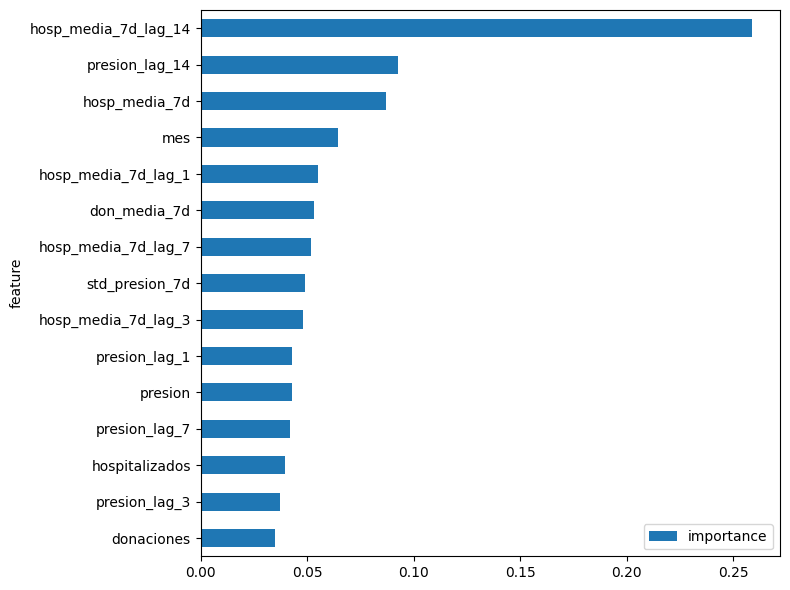

In [ ]:
importancias.head(15).sort_values("importancia").plot(
    x="feature", y="importancia", kind="barh", figsize=(8, 6)
)

plt.tight_layout()
plt.show()